### PowerCo Data Science Project

### Exploratory Data Analysis & Churn Drivers

In [165]:
import matplotlib.pyplot as plt #import packages
import seaborn as sns
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f'% x)


In [166]:
client_df = pd.read_csv('client_data.csv') #loading Data
price_df = pd.read_csv('price_data.csv')

In [167]:
client_df.head(5)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.65,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.80,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.86,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.20,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.80,0


In [168]:
price_df.head(5)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.15,0.00,0.00,44.27,0.00,0.00
1,038af19179925da21a25619c5a24b745,2015-02-01,0.15,0.00,0.00,44.27,0.00,0.00
2,038af19179925da21a25619c5a24b745,2015-03-01,0.15,0.00,0.00,44.27,0.00,0.00
3,038af19179925da21a25619c5a24b745,2015-04-01,0.15,0.00,0.00,44.27,0.00,0.00
4,038af19179925da21a25619c5a24b745,2015-05-01,0.15,0.00,0.00,44.27,0.00,0.00


In [169]:
client_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [170]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


#### Descriptive Stastistics

In [172]:
client_df.describe() 

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00,14606.00
mean,159220.29,28092.38,16090.27,1868.61,1399.76,0.97,63.09,0.14,0.05,43.13,152.79,24.57,24.56,1.29,189.26,5.00,18.14,0.10
std,573465.26,162973.06,64364.20,2387.57,3247.79,5.11,66.17,0.02,0.05,4.49,341.37,20.23,20.23,0.71,311.80,1.61,13.53,0.30
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,3.30,0.00
25%,5674.75,0.00,0.00,495.00,0.00,0.00,16.18,0.12,0.00,40.61,0.00,14.28,14.28,1.00,50.71,4.00,12.50,0.00
50%,14115.50,0.00,792.50,1112.88,314.00,0.00,18.80,0.14,0.08,44.31,37.39,21.64,21.64,1.00,112.53,5.00,13.86,0.00
75%,40763.75,0.00,3383.00,2401.79,1745.75,0.00,131.03,0.15,0.10,44.31,193.98,29.88,29.88,1.00,243.10,6.00,19.17,0.00
max,6207104.00,4154590.00,771203.00,82902.83,175375.00,30.00,599.31,0.27,0.20,59.27,15042.79,374.64,374.64,32.00,24570.65,13.00,320.00,1.00


In [173]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.00,193002.00,193002.00,193002.00,193002.00,193002.00
mean,0.14,0.05,0.03,43.33,10.62,6.41
std,0.03,0.05,0.04,5.41,12.84,7.77
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.13,0.00,0.00,40.73,0.00,0.00
50%,0.15,0.09,0.00,44.27,0.00,0.00
75%,0.15,0.10,0.07,44.44,24.34,16.23
max,0.28,0.23,0.11,59.44,36.49,17.46


#### Data Preprocessing & Feature Engineering

In [175]:
date_cols = ['date_activ','date_end','date_modif_prod','date_renewal']
for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors = 'coerce')

In [176]:
price_df['price_date'] = pd.to_datetime(price_df['price_date'], errors = 'coerce')

In [177]:
client_df['tenure']= (client_df['date_end']- client_df['date_activ']).dt.days /365

In [178]:
avg_prices = price_df.groupby('id').agg({'price_off_peak_var': 'mean', 'price_peak_var':'mean'}).reset_index()

In [179]:
df = client_df.merge(avg_prices, on='id', how = 'left')

In [180]:
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn,tenure,price_off_peak_var,price_peak_var
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.65,1,3.00,0.12,0.10
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.80,0,7.03,0.15,0.01
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.86,0,6.01,0.17,0.09
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.20,0,6.01,0.15,0.00
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.80,0,6.15,0.12,0.10


In [181]:
df['avg_prices'] = (df['price_off_peak_var']+ df['price_peak_var']) / 2

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  object        
 1   channel_sales                   14606 non-null  object        
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  fo

### Data Visualization

### Churn Distribution

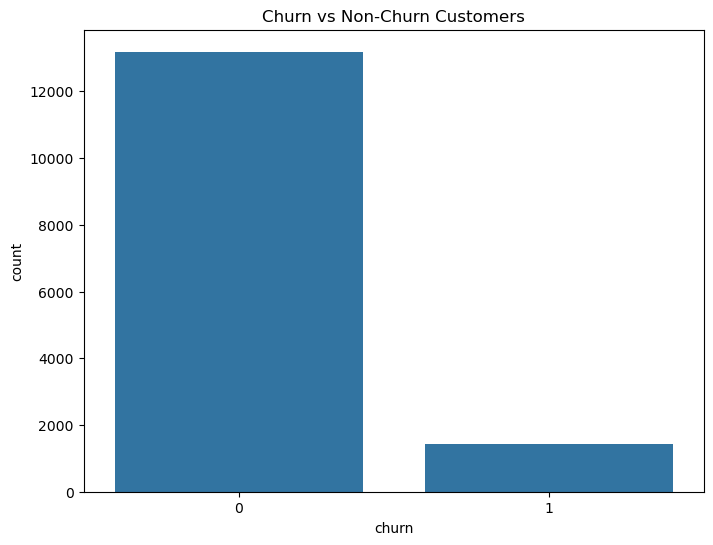

In [185]:
plt.figure(figsize=(8,6))
sns.countplot(x='churn' , data=df)
plt.title('Churn vs Non-Churn Customers')
plt.show()

#### Analysis: The dataset shows a baseline churn rate of 9.72%. While the majority of customers remain active, nearly 10% attrition represents a significant revenue loss that requires a proactive retention strategy.

In [187]:
churn_rate =df['churn'].mean()*100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 9.72%


### Price Sensitivity

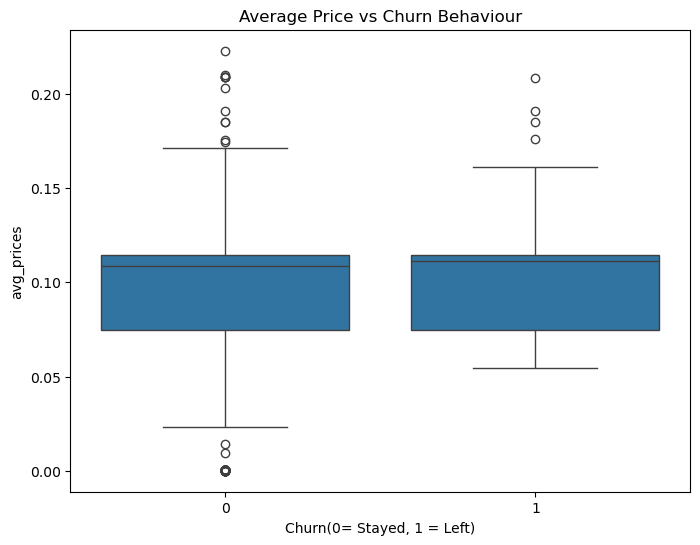

In [189]:
plt.figure(figsize=(8,6))
sns.boxplot(x="churn", y = 'avg_prices' , data= df)
plt.title('Average Price vs Churn Behaviour')
plt.xlabel('Churn(0= Stayed, 1 = Left)')
plt.show()

#### Analysis: The price distributions for churned and retained customers are nearly identical. This confirms that price sensitivity is not the primary driver of churn, suggesting that price cuts alone will not improve retention.

### Sales Channel Analysis

In [192]:
top_channels = df['channel_sales'].value_counts().head(5).index

Text(0.5, 1.0, 'Churn by Top Sales Channel')

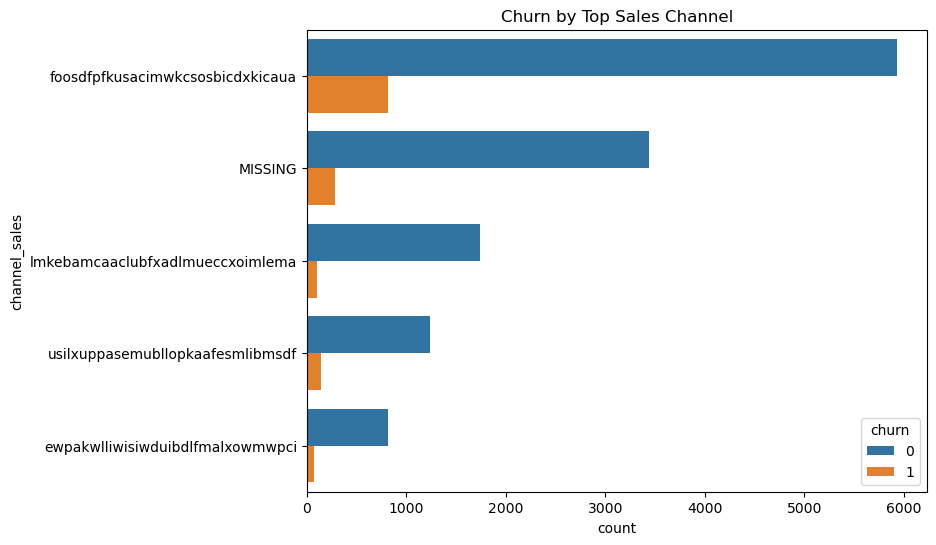

In [193]:
plt.figure(figsize=(8, 6))
sns.countplot(y = 'channel_sales',hue='churn', data= df[df['channel_sales'].isin(top_channels)])
plt.title('Churn by Top Sales Channel')

#### Analysis: The foosdfpfkusacimwkcsosbicdxkicaua channel has the highest volume of both total and churned customers. The high number of "MISSING" values indicates a data quality gap that needs to be addressed to better optimize sales strategies.

### Customer Tenure(Antiquity)

Text(0.5, 0, 'Years as Customer')

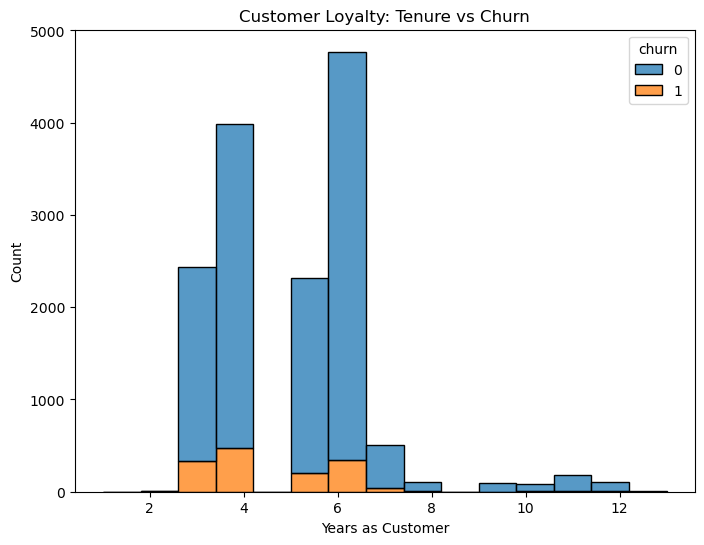

In [196]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='num_years_antig', hue='churn', multiple='stack', bins=15)
plt.title('Customer Loyalty: Tenure vs Churn')
plt.xlabel('Years as Customer')


#### Analysis: Churn is most concentrated among customers with 3 to 6 years of tenure. Loyalty significantly increases after year 7, indicating that the first few years are the highest risk period for customer exit.

### Consumption Analysis (Annual Consumption) 

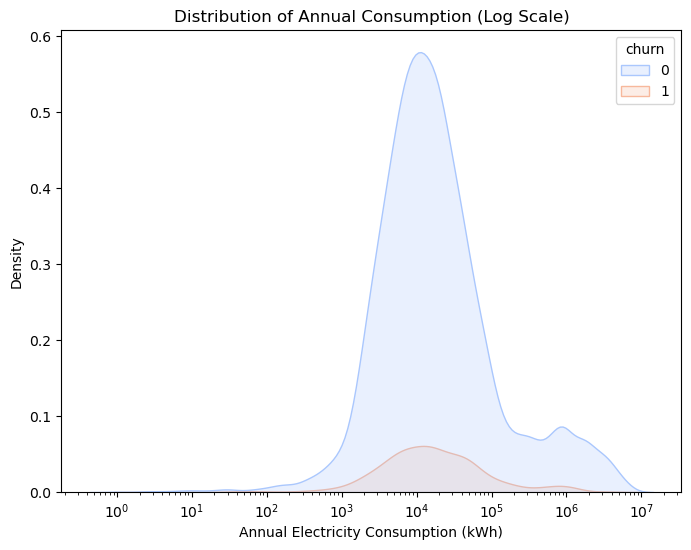

In [199]:
positive_cons = df[df['cons_12m'] > 0]
plt.figure(figsize=(8, 6))
sns.kdeplot(data=positive_cons, x='cons_12m', hue='churn', fill=True, log_scale=True, palette='coolwarm')

plt.title('Distribution of Annual Consumption (Log Scale)')
plt.xlabel('Annual Electricity Consumption (kWh)')
plt.ylabel('Density')
plt.show()

#### Analysis: Churners follow the general population’s consumption distribution, peaking around 10^4 kWh. There is no clear evidence that high-volume or low-volume customers are more likely to churn based on usage alone.

### Correlation Heatmap 

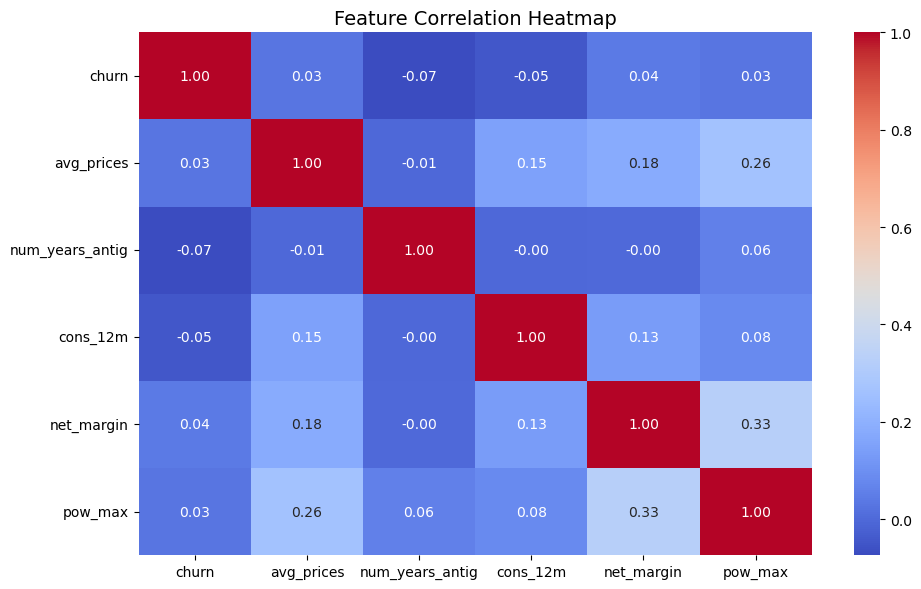

In [202]:
plt.figure(figsize=(10,6))
relevant_cols = ['churn', 'avg_prices', 'num_years_antig', 'cons_12m', 'net_margin', 'pow_max']
sns.heatmap(df[relevant_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

#### Analysis: All features show very weak linear correlations (< 0.1) with churn. This indicates that churn is driven by a complex combination of factors rather than a single variable, necessitating a non-linear machine learning model like Random Forest.

#### Executive Summary: Our analysis proves that customer churn at PowerCo is not primarily driven by price. Instead, it is influenced by customer tenure and specific sales channels. To accurately predict and prevent churn, we must move beyond simple analysis and build a predictive model that captures the non-linear relationships between these features.